In [1]:
#!pip install pandas matplotlib seaborn sklearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys

# Cargar el dataset
df = pd.read_csv(r"C:\Users\Ing. Antonio Rial\OneDrive - Universidad Austral\MCD_Laboratorio.de.Implementación.2\Competencia.House.Pricing\data\tabular\train_processed.csv", low_memory=False)


In [2]:

# ============================================================
# 1. RESUMEN GENERAL DE VALORES FALTANTES
# ============================================================
print("=" * 70)
print("1. RESUMEN GENERAL DE VALORES FALTANTES")
print("=" * 70)

total_celdas = df.shape[0] * df.shape[1]
total_nulos = df.isnull().sum().sum()
pct_nulos_total = (total_nulos / total_celdas) * 100

print(f"Total de celdas en el dataset:     {total_celdas:,}")
print(f"Total de valores faltantes:        {total_nulos:,}")
print(f"Porcentaje global de faltantes:    {pct_nulos_total:.2f}%")
print(f"Filas con al menos un faltante:    {df.isnull().any(axis=1).sum():,} ({df.isnull().any(axis=1).sum()/len(df)*100:.2f}%)")
print(f"Filas completas (sin faltantes):   {df.dropna().shape[0]:,} ({df.dropna().shape[0]/len(df)*100:.2f}%)")


1. RESUMEN GENERAL DE VALORES FALTANTES
Total de celdas en el dataset:     544,640
Total de valores faltantes:        18,522
Porcentaje global de faltantes:    3.40%
Filas con al menos un faltante:    7,883 (66.58%)
Filas completas (sin faltantes):   3,957 (33.42%)


In [3]:

# ============================================================
# 2. DETALLE POR COLUMNA
# ============================================================
print("\n" + "=" * 70)
print("2. DETALLE DE VALORES FALTANTES POR COLUMNA")
print("=" * 70)

missing = pd.DataFrame({
    'Columna': df.columns,
    'Tipo': df.dtypes.values,
    'No_Nulos': df.count().values,
    'Nulos': df.isnull().sum().values,
    'Pct_Nulos': (df.isnull().sum().values / len(df) * 100).round(2),
    'Valores_Unicos': [df[col].nunique() for col in df.columns]
})
missing = missing.sort_values('Pct_Nulos', ascending=False)
missing['Severidad'] = missing['Pct_Nulos'].apply(
    lambda x: '🔴 CRÍTICO (>40%)' if x > 40 
    else '🟠 ALTO (20-40%)' if x > 20 
    else '🟡 MODERADO (5-20%)' if x > 5 
    else '🟢 BAJO (<5%)' if x > 0 
    else '✅ COMPLETO'
)

print(missing.to_string(index=False))



2. DETALLE DE VALORES FALTANTES POR COLUMNA
                   Columna    Tipo  No_Nulos  Nulos  Pct_Nulos  Valores_Unicos        Severidad
              lotAreaValue float64      6494   5346      45.15            2083 🔴 CRÍTICO (>40%)
              log_lot_area float64      6494   5346      45.15            2083 🔴 CRÍTICO (>40%)
        last_listing_price float64      7915   3925      33.15            1593  🟠 ALTO (20-40%)
         bath_to_bed_ratio float64     11258    582       4.92              38     🟢 BAJO (<5%)
           latest_tax_paid float64     11301    539       4.55           10505     🟢 BAJO (<5%)
          taxAssessedValue float64     11316    524       4.43           10381     🟢 BAJO (<5%)
          latest_tax_value float64     11315    525       4.43           10380     🟢 BAJO (<5%)
                  bedrooms float64     11360    480       4.05              11     🟢 BAJO (<5%)
              property_age float64     11529    311       2.63             110     🟢 BAJO (


✅ Gráfico guardado: missing_values_analysis.png


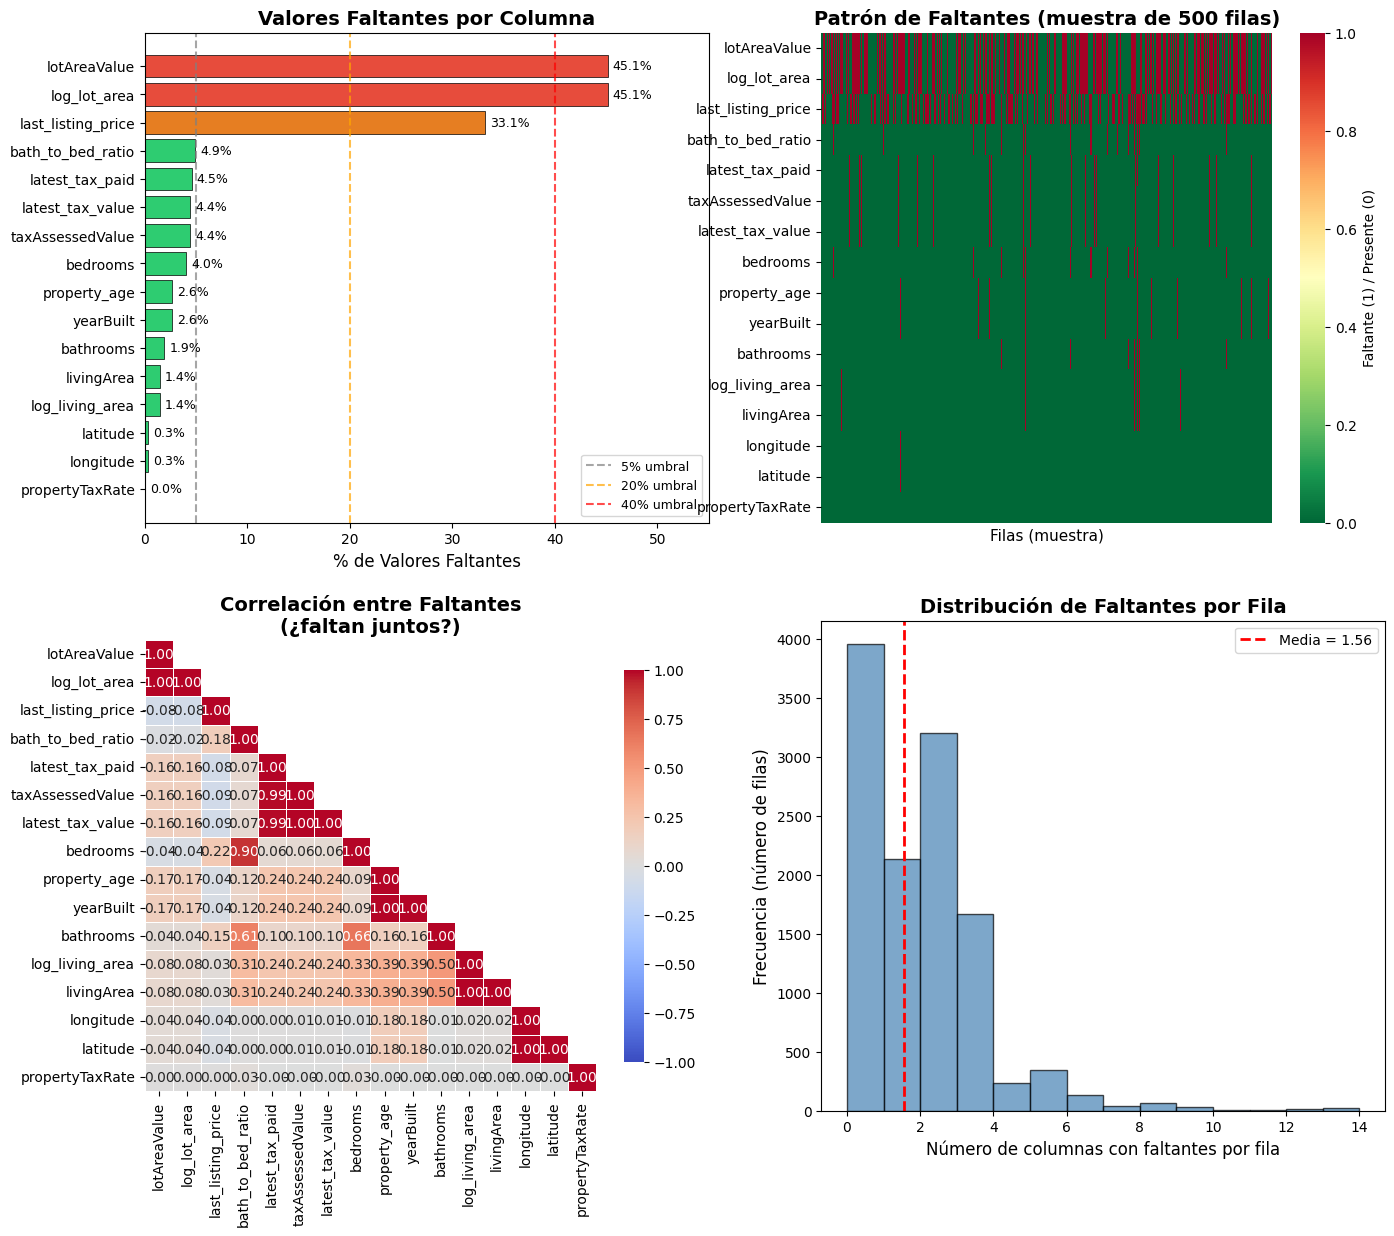

In [4]:

# ============================================================
# 3. VISUALIZACIONES DE VALORES FALTANTES
# ============================================================

# Figura 1: Barras horizontales de % de faltantes por columna
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# --- Gráfico 1: Barras horizontales ---
ax1 = axes[0, 0]
missing_plot = missing[missing['Nulos'] > 0].sort_values('Pct_Nulos', ascending=True)
colors = ['#e74c3c' if x > 40 else '#e67e22' if x > 20 else '#f1c40f' if x > 5 else '#2ecc71' 
          for x in missing_plot['Pct_Nulos']]
bars = ax1.barh(missing_plot['Columna'], missing_plot['Pct_Nulos'], color=colors, edgecolor='black', linewidth=0.5)
ax1.set_xlabel('% de Valores Faltantes', fontsize=12)
ax1.set_title('Valores Faltantes por Columna', fontsize=14, fontweight='bold')
ax1.axvline(x=5, color='gray', linestyle='--', alpha=0.7, label='5% umbral')
ax1.axvline(x=20, color='orange', linestyle='--', alpha=0.7, label='20% umbral')
ax1.axvline(x=40, color='red', linestyle='--', alpha=0.7, label='40% umbral')
for bar, pct in zip(bars, missing_plot['Pct_Nulos']):
    ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
             f'{pct:.1f}%', va='center', fontsize=9)
ax1.legend(loc='lower right', fontsize=9)
ax1.set_xlim(0, 55)

# --- Gráfico 2: Mapa de calor de faltantes (muestra) ---
ax2 = axes[0, 1]
cols_con_nulos = missing[missing['Nulos'] > 0]['Columna'].tolist()
df_nulos = df[cols_con_nulos].isnull().astype(int)
# Muestra aleatoria de 500 filas para visualización
np.random.seed(42)
sample_idx = np.random.choice(df_nulos.index, size=min(500, len(df_nulos)), replace=False)
df_sample = df_nulos.loc[sample_idx]
sns.heatmap(df_sample.T, cbar=True, cmap='RdYlGn_r', ax=ax2, 
            xticklabels=False, yticklabels=True, cbar_kws={'label': 'Faltante (1) / Presente (0)'})
ax2.set_title('Patrón de Faltantes (muestra de 500 filas)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Filas (muestra)', fontsize=11)

# --- Gráfico 3: Matriz de correlación de faltantes ---
ax3 = axes[1, 0]
# Calcular correlación entre columnas con faltantes (solo las que tienen nulos)
cols_nulos = [c for c in cols_con_nulos if df[c].isnull().sum() > 0]
if len(cols_nulos) > 1:
    null_corr = df[cols_nulos].isnull().corr()
    mask = np.triu(np.ones_like(null_corr, dtype=bool), k=1)
    sns.heatmap(null_corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, ax=ax3, square=True, linewidths=0.5,
                vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
    ax3.set_title('Correlación entre Faltantes\n(¿faltan juntos?)', fontsize=14, fontweight='bold')
else:
    ax3.text(0.5, 0.5, 'Insuficientes columnas\ncon faltantes', ha='center', va='center', fontsize=12)
    ax3.set_title('Correlación entre Faltantes', fontsize=14, fontweight='bold')

# --- Gráfico 4: Distribución de faltantes por fila ---
ax4 = axes[1, 1]
nulos_por_fila = df.isnull().sum(axis=1)
ax4.hist(nulos_por_fila, bins=range(0, nulos_por_fila.max()+2), color='steelblue', 
         edgecolor='black', alpha=0.7)
ax4.set_xlabel('Número de columnas con faltantes por fila', fontsize=12)
ax4.set_ylabel('Frecuencia (número de filas)', fontsize=12)
ax4.set_title('Distribución de Faltantes por Fila', fontsize=14, fontweight='bold')
ax4.axvline(x=nulos_por_fila.mean(), color='red', linestyle='--', linewidth=2, 
            label=f'Media = {nulos_por_fila.mean():.2f}')
ax4.legend(fontsize=10)

#plt.tight_layout()
#plt.savefig('/mnt/agents/output/missing_values_analysis.png', dpi=150, bbox_inches='tight')
#plt.show()

print("\n✅ Gráfico guardado: missing_values_analysis.png")


In [5]:

# ============================================================
# 4. ANÁLISIS DE PATRONES DE FALTANTES
# ============================================================
print("=" * 70)
print("4. ANÁLISIS DE PATRONES DE FALTANTES (MCAR, MAR, MNAR)")
print("=" * 70)

# --- Patrón 1: lotAreaValue y log_lot_area ---
print("\n📌 PATRÓN 1: lotAreaValue ↔ log_lot_area")
print("-" * 50)
lot_nulos = df['lotAreaValue'].isnull()
loglot_nulos = df['log_lot_area'].isnull()
print(f"lotAreaValue faltantes:        {lot_nulos.sum()}")
print(f"log_lot_area faltantes:        {loglot_nulos.sum()}")
print(f"Ambos faltan juntos:           {(lot_nulos & loglot_nulos).sum()}")
print(f"Correlación de faltantes:      {lot_nulos.corr(loglot_nulos):.4f}")
print("→ Son la misma variable transformada. Se pierden juntos (determinístico).")

# --- Patrón 2: Variables fiscales ---
print("\n📌 PATRÓN 2: Variables fiscales (taxAssessedValue, latest_tax_value, latest_tax_paid)")
print("-" * 50)
tax_cols = ['taxAssessedValue', 'latest_tax_value', 'latest_tax_paid']
for col in tax_cols:
    nulos = df[col].isnull().sum()
    print(f"{col}: {nulos} faltantes ({nulos/len(df)*100:.2f}%)")

# ¿Faltan juntas?
tax_missing = df[tax_cols].isnull()
juntas = (tax_missing.sum(axis=1) == 3).sum()
print(f"Filas donde faltan las 3 juntas: {juntas}")
print(f"Correlación taxAssessedValue ↔ latest_tax_value: {tax_missing.iloc[:,0].corr(tax_missing.iloc[:,1]):.4f}")
print(f"Correlación taxAssessedValue ↔ latest_tax_paid:  {tax_missing.iloc[:,0].corr(tax_missing.iloc[:,2]):.4f}")

# --- Patrón 3: bedrooms, bathrooms, livingArea ---
print("\n📌 PATRÓN 3: Características físicas (bedrooms, bathrooms, livingArea)")
print("-" * 50)
phys_cols = ['bedrooms', 'bathrooms', 'livingArea', 'log_living_area', 'bath_to_bed_ratio']
phys_missing = df[phys_cols].isnull()
print("Faltantes por columna:")
for col in phys_cols:
    print(f"  {col}: {df[col].isnull().sum()}")
print(f"Filas donde faltan bedrooms Y bathrooms: {(df['bedrooms'].isnull() & df['bathrooms'].isnull()).sum()}")
print(f"Filas donde faltan livingArea Y log_living_area: {(df['livingArea'].isnull() & df['log_living_area'].isnull()).sum()}")

# --- Patrón 4: yearBuilt ↔ property_age ---
print("\n📌 PATRÓN 4: yearBuilt ↔ property_age")
print("-" * 50)
yb_null = df['yearBuilt'].isnull()
pa_null = df['property_age'].isnull()
print(f"yearBuilt faltantes:     {yb_null.sum()}")
print(f"property_age faltantes:  {pa_null.sum()}")
print(f"Ambos faltan juntos:     {(yb_null & pa_null).sum()}")
print(f"Correlación:             {yb_null.corr(pa_null):.4f}")
print("→ Son la misma información (property_age = año_actual - yearBuilt).")

# --- Patrón 5: latitude ↔ longitude ---
print("\n📌 PATRÓN 5: latitude ↔ longitude")
print("-" * 50)
lat_null = df['latitude'].isnull()
lon_null = df['longitude'].isnull()
print(f"latitude faltantes:   {lat_null.sum()}")
print(f"longitude faltantes:  {lon_null.sum()}")
print(f"Ambos faltan juntos:  {(lat_null & lon_null).sum()}")
print(f"Correlación:          {lat_null.corr(lon_null):.4f}")
print("→ Coordenadas geográficas: si falta una, falta la otra.")


4. ANÁLISIS DE PATRONES DE FALTANTES (MCAR, MAR, MNAR)

📌 PATRÓN 1: lotAreaValue ↔ log_lot_area
--------------------------------------------------
lotAreaValue faltantes:        5346
log_lot_area faltantes:        5346
Ambos faltan juntos:           5346
Correlación de faltantes:      1.0000
→ Son la misma variable transformada. Se pierden juntos (determinístico).

📌 PATRÓN 2: Variables fiscales (taxAssessedValue, latest_tax_value, latest_tax_paid)
--------------------------------------------------
taxAssessedValue: 524 faltantes (4.43%)
latest_tax_value: 525 faltantes (4.43%)
latest_tax_paid: 539 faltantes (4.55%)
Filas donde faltan las 3 juntas: 524
Correlación taxAssessedValue ↔ latest_tax_value: 0.9990
Correlación taxAssessedValue ↔ latest_tax_paid:  0.9853

📌 PATRÓN 3: Características físicas (bedrooms, bathrooms, livingArea)
--------------------------------------------------
Faltantes por columna:
  bedrooms: 480
  bathrooms: 225
  livingArea: 172
  log_living_area: 172
  bath_to

#### Estrategias recomendadas según el tipo de columna  
🔢 Variables numéricas continuas (precio, sqft, coordenadas, etc.)  
|Situación|Estrategia recomendada|  
| :--- | :---: |  
|< 5% missing|Mediana (robusta a outliers) o imputación por KNN|
|5-20% missing|Imputación iterativa (IterativeImputer) o modelo predictivo|
|> 20% missing|Evaluar si la columna aporta valor; considerar eliminar o crear flag de missing|

✅ Columnas recomendadas para mediana:  

| Columna | Tipo | Por qué mediana |
|---------|------|-----------------|
| bedrooms | Numérica discreta | Valores como 2, 3, 4; robusta a outliers |
| bathrooms | Numérica (con decimales) | Valores como 2.0, 2.5, 3.0; distribución no normal |
| sqft | Continua | Típicamente sesgada a la derecha, mediana más representativa |
| year_built | Numérica | La mediana evita que valores extremos distorsionen |
| lot_size | Continua | Muy probable que tenga outliers, mediana es robusta |
| price / rent | Continua | Distribución altamente sesgada, mediana >> media |
| hoa_fee, tax_amount (si existen) | Continua | Mismo razonamiento que precio |

In [6]:
import pandas as pd
import numpy as np
import importlib.util, sys, subprocess
if importlib.util.find_spec("sklearn") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "scikit-learn"])
from sklearn.impute import SimpleImputer

#df = pd.read_csv('train_processed.csv')

# Columnas candidatas para mediana (según tu tabla)
median_candidates = ['bedrooms', 'bathrooms', 'sqft', 'year_built', 'lot_size', 'price', 'rent', 'hoa_fee']

# Filtrar solo las que existen en el dataset y tienen missing values
cols_to_impute = [col for col in median_candidates if col in df.columns and df[col].isnull().any()]

print(f"Columnas a imputar con mediana: {cols_to_impute}")

# Aplicar imputación
if cols_to_impute:
    imputer = SimpleImputer(strategy='median')
    df[cols_to_impute] = imputer.fit_transform(df[cols_to_impute])
    
    # Opcional: crear flags para variables críticas
    for col in ['price', 'sqft', 'bedrooms']:
        if col in cols_to_impute:
            df[f'{col}_was_missing'] = df[col].isnull().astype(int)

Columnas a imputar con mediana: ['bedrooms', 'bathrooms']


✅ Columnas candidatas para Imputación Iterativa en tu dataset:  
  
|Columna|Por qué funciona con IterativeImputer|Variables relacionadas para predecir|
|-------|-------------------------------------|------------------------------------|
|price / rent|Altamente correlacionadas con sqft, ubicación, características|sqft, bedrooms, bathrooms, zip_code, property_type|
|sqft|Se relaciona con precio, habitaciones, tipo de propiedad|price, bedrooms, bathrooms, lot_size|
|lot_size|Correlacionada con tipo de propiedad, ubicación, precio|property_type, zip_code, price, year_built|
|year_built|Puede inferirse por estilo, ubicación, valor de la propiedad|property_type, zip_code, price, hoa_fee|
|latitude / longitude|Fuertemente ligadas a zip_code y características del área|zip_code, property_type, price|
|hoa_fee / tax_amount|Dependen del valor de la propiedad y ubicación|price, property_type, zip_code, sqft|

In [7]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import pandas as pd
import numpy as np

#df = pd.read_csv('train_processed.csv')

# Seleccionar columnas numéricas candidatas
iterative_candidates = ['bedrooms', 'bathrooms']
#iterative_candidates = ['sqft', 'lot_size', 'year_built', 
#                        'latitude', 'longitude', 'hoa_fee', 'tax_amount']
#iterative_candidates = ['price', 'sqft', 'lot_size', 'year_built', 
#                        'latitude', 'longitude', 'hoa_fee', 'tax_amount']

# Filtrar solo las que existen y tienen missing
cols_to_impute = [col for col in iterative_candidates if col in df.columns and df[col].isnull().any()]

if cols_to_impute:
    # Configurar imputador iterativo
    imputer = IterativeImputer(
        random_state=42, 
        max_iter=10, 
        tol=1e-3,
        sample_posterior=False  # Más rápido para datasets grandes
    )
    
    # Aplicar imputación
    df[cols_to_impute] = imputer.fit_transform(df[cols_to_impute])
    
    print(f"✓ Imputación iterativa aplicada a: {cols_to_impute}")

In [ ]:
# 1. Categóricas → categoría 'Missing'
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna('Missing')

# 2. Numéricas con <5% missing → Mediana (rápido)
# 1. Categóricas → categoría 'Missing'
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna('Missing')

# 2. Numéricas con <5% missing → Mediana (rápido)
num_cols = df.select_dtypes(include=[np.number]).columns
low_missing = [col for col in num_cols if 0 < df[col].isnull().sum() / len(df) < 0.05]

if low_missing:
    df[low_missing] = SimpleImputer(strategy='median').fit_transform(df[low_missing])

# 3. Numéricas con 5-30% missing y correlaciones → IterativeImputer
high_corr_cols = ['price', 'sqft', 'lot_size', 'year_built']  # ajustar según análisis
# 1. Categóricas → categoría 'Missing'
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna('Missing')

# 2. Numéricas con <5% missing → Mediana (rápido)
num_cols = df.select_dtypes(include=[np.number]).columns
low_missing = [col for col in num_cols if 0 < df[col].isnull().sum() / len(df) < 0.05]

if low_missing:
    df[low_missing] = SimpleImputer(strategy='median').fit_transform(df[low_missing])

# 3. Numéricas con 5-30% missing y correlaciones → IterativeImputer
high_corr_cols = [col for col in num_cols if 0.05 <= df[col].isnull().sum() / len(df) <= 0.30]

if high_corr_cols:
    df[high_corr_cols] = IterativeImputer(random_state=42).fit_transform(df[high_corr_cols])
# 1. Categóricas → categoría 'Missing'
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna('Missing')

# 2. Numéricas con <5% missing → Mediana (rápido)
num_cols = df.select_dtypes(include=[np.number]).columns
low_missing = [col for col in num_cols if 0 < df[col].isnull().sum() / len(df) < 0.05]

if low_missing:
    df[low_missing] = SimpleImputer(strategy='median').fit_transform(df[low_missing])

# 3. Numéricas con 5-30% missing y correlaciones → IterativeImputer
high_corr_cols = [col for col in num_cols if 0.05 <= df[col].isnull().sum() / len(df) <= 0.30]

if high_corr_cols:
    df[high_corr_cols] = IterativeImputer(random_state=42).fit_transform(df[high_corr_cols])

# 3. Numéricas con 5-30% missing y correlaciones → IterativeImputer
high_corr_cols = ['price', 'sqft', 'lot_size', 'year_built']  # ajustar según análisis
valid_high_corr_cols = [col for col in high_corr_cols if col in df.columns]
if valid_high_corr_cols:
    df[valid_high_corr_cols] = IterativeImputer(random_state=42).fit_transform(df[valid_high_corr_cols])